# Data Collection and Cleaning

For this project, we analyze a portfolio of the following:

- **SPY** 25%
- **QQQ** 15%
- **IEF** 20%
- **TLT** 10%
- **LQD** 10%
- **GLD** 10%
- **VNQ** 10%

We pull daily adjusted prices of all 7 assests from 2007 ~ 2025 using Yahoo Finance as the data source.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import yfinance as yf
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

## Data ingestion and cleaning

In [2]:
tickers = ['SPY', 'QQQ', 'IEF', 'TLT', 'LQD', 'GLD', 'VNQ']
asset_weights = np.array([0.25, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10])

start_date = "2005-01-01"
end_date = "2025-12-31"

In [75]:
def load_price(tickers: list, start, end):
    prices = []
    for ticker in tickers:
        price = yf.download(ticker, start=start, end=end, auto_adjust=True)
        prices.append(price)
    return pd.concat(map(lambda x: x.Close, prices), axis=1)

prices_df = load_price(tickers, start_date, end_date)

/Users/williamchen/projects/VaR_model/env/lib/python3.13/site-packages/yfinance/scrapers/history.py:188: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/Users/williamchen/projects/VaR_model/env/lib/python3.13/site-packages/yfinance/scrapers/history.py:188: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/Users/williamchen/projects/VaR_model/env/lib/python3.13/site-packages/yfinance/scrapers/history.py:188: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/Users/willia

In [76]:
prices_df.head()

Ticker,SPY,QQQ,IEF,TLT,LQD,GLD,VNQ
Date,,,,,,,
2005-01-03,81.383743,33.695396,48.410694,44.738461,47.897339,43.020000,22.788918
2005-01-04,80.389267,33.081177,48.109249,44.269600,47.628513,42.740002,22.446415
2005-01-05,79.834534,32.876450,48.188889,44.506561,47.666943,42.669998,21.700241
2005-01-06,80.240417,32.714375,48.234390,44.536819,47.701069,42.150002,21.867405
2005-01-07,80.125435,32.884975,48.194607,44.637646,47.679699,41.840000,21.818483


In [77]:
# Check missing values and misaligned dates
print("Missing value counts:")
print((prices_df.isna() == True).sum())

Missing value counts:
Ticker
SPY    0
QQQ    0
IEF    0
TLT    0
LQD    0
GLD    0
VNQ    0
dtype: int64


In [78]:
# Calculate log returns
def get_log_return(prices: pd.DataFrame):
    return np.log(prices / prices.shift()).dropna()

log_returns = get_log_return(prices_df)
log_returns['Portfolio'] = log_returns @ asset_weights   # Add portfolio return column

In [79]:
log_returns.describe()

Ticker,SPY,QQQ,IEF,TLT,LQD,GLD,VNQ,Portfolio
count,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000
mean,0.000403,0.000551,0.000129,0.000126,0.000157,0.000422,0.000258,0.000306
std,0.012012,0.013641,0.004276,0.009243,0.005381,0.011143,0.018163,0.006587
min,-0.115887,-0.127593,-0.025392,-0.069010,-0.095533,-0.091905,-0.217083,-0.058718
25%,-0.003951,-0.005189,-0.002423,-0.005368,-0.002137,-0.005089,-0.006469,-0.002590
50%,0.000717,0.001148,0.000229,0.000446,0.000369,0.000595,0.000760,0.000655
75%,0.005786,0.007322,0.002624,0.005526,0.002580,0.006228,0.007515,0.003372
max,0.135577,0.114798,0.033688,0.072503,0.093197,0.106974,0.157059,0.058490


In [80]:
# Export price and log return data
prices_df.to_csv("../data/prices.csv")
log_returns.to_csv("../data/returns.csv")

## Explanatory Data Analysis

We examine:
- Log return series plots
- QQ-plots for each asset
- Autocorrelation of squared returns for each asset
- Correlations between assets

and keep an eye on behavior during key regimes:
- 2007-2009 Global financial crisis
- 2020 Covid crash
- 2022 Rate shock

In [81]:
# Key regimes
REGIMES = {
    'GFC': ['2007-08-01', '2009-03-31', 'red'],
    'Covid_Crash': ['2020-02-01', '2020-03-31', 'orange'],
    'Post_Covid': ['2020-04-01', '2021-12-31', 'green'],
    '2022_Shock': ['2022-01-01', '2022-12-31', 'purple'],
}

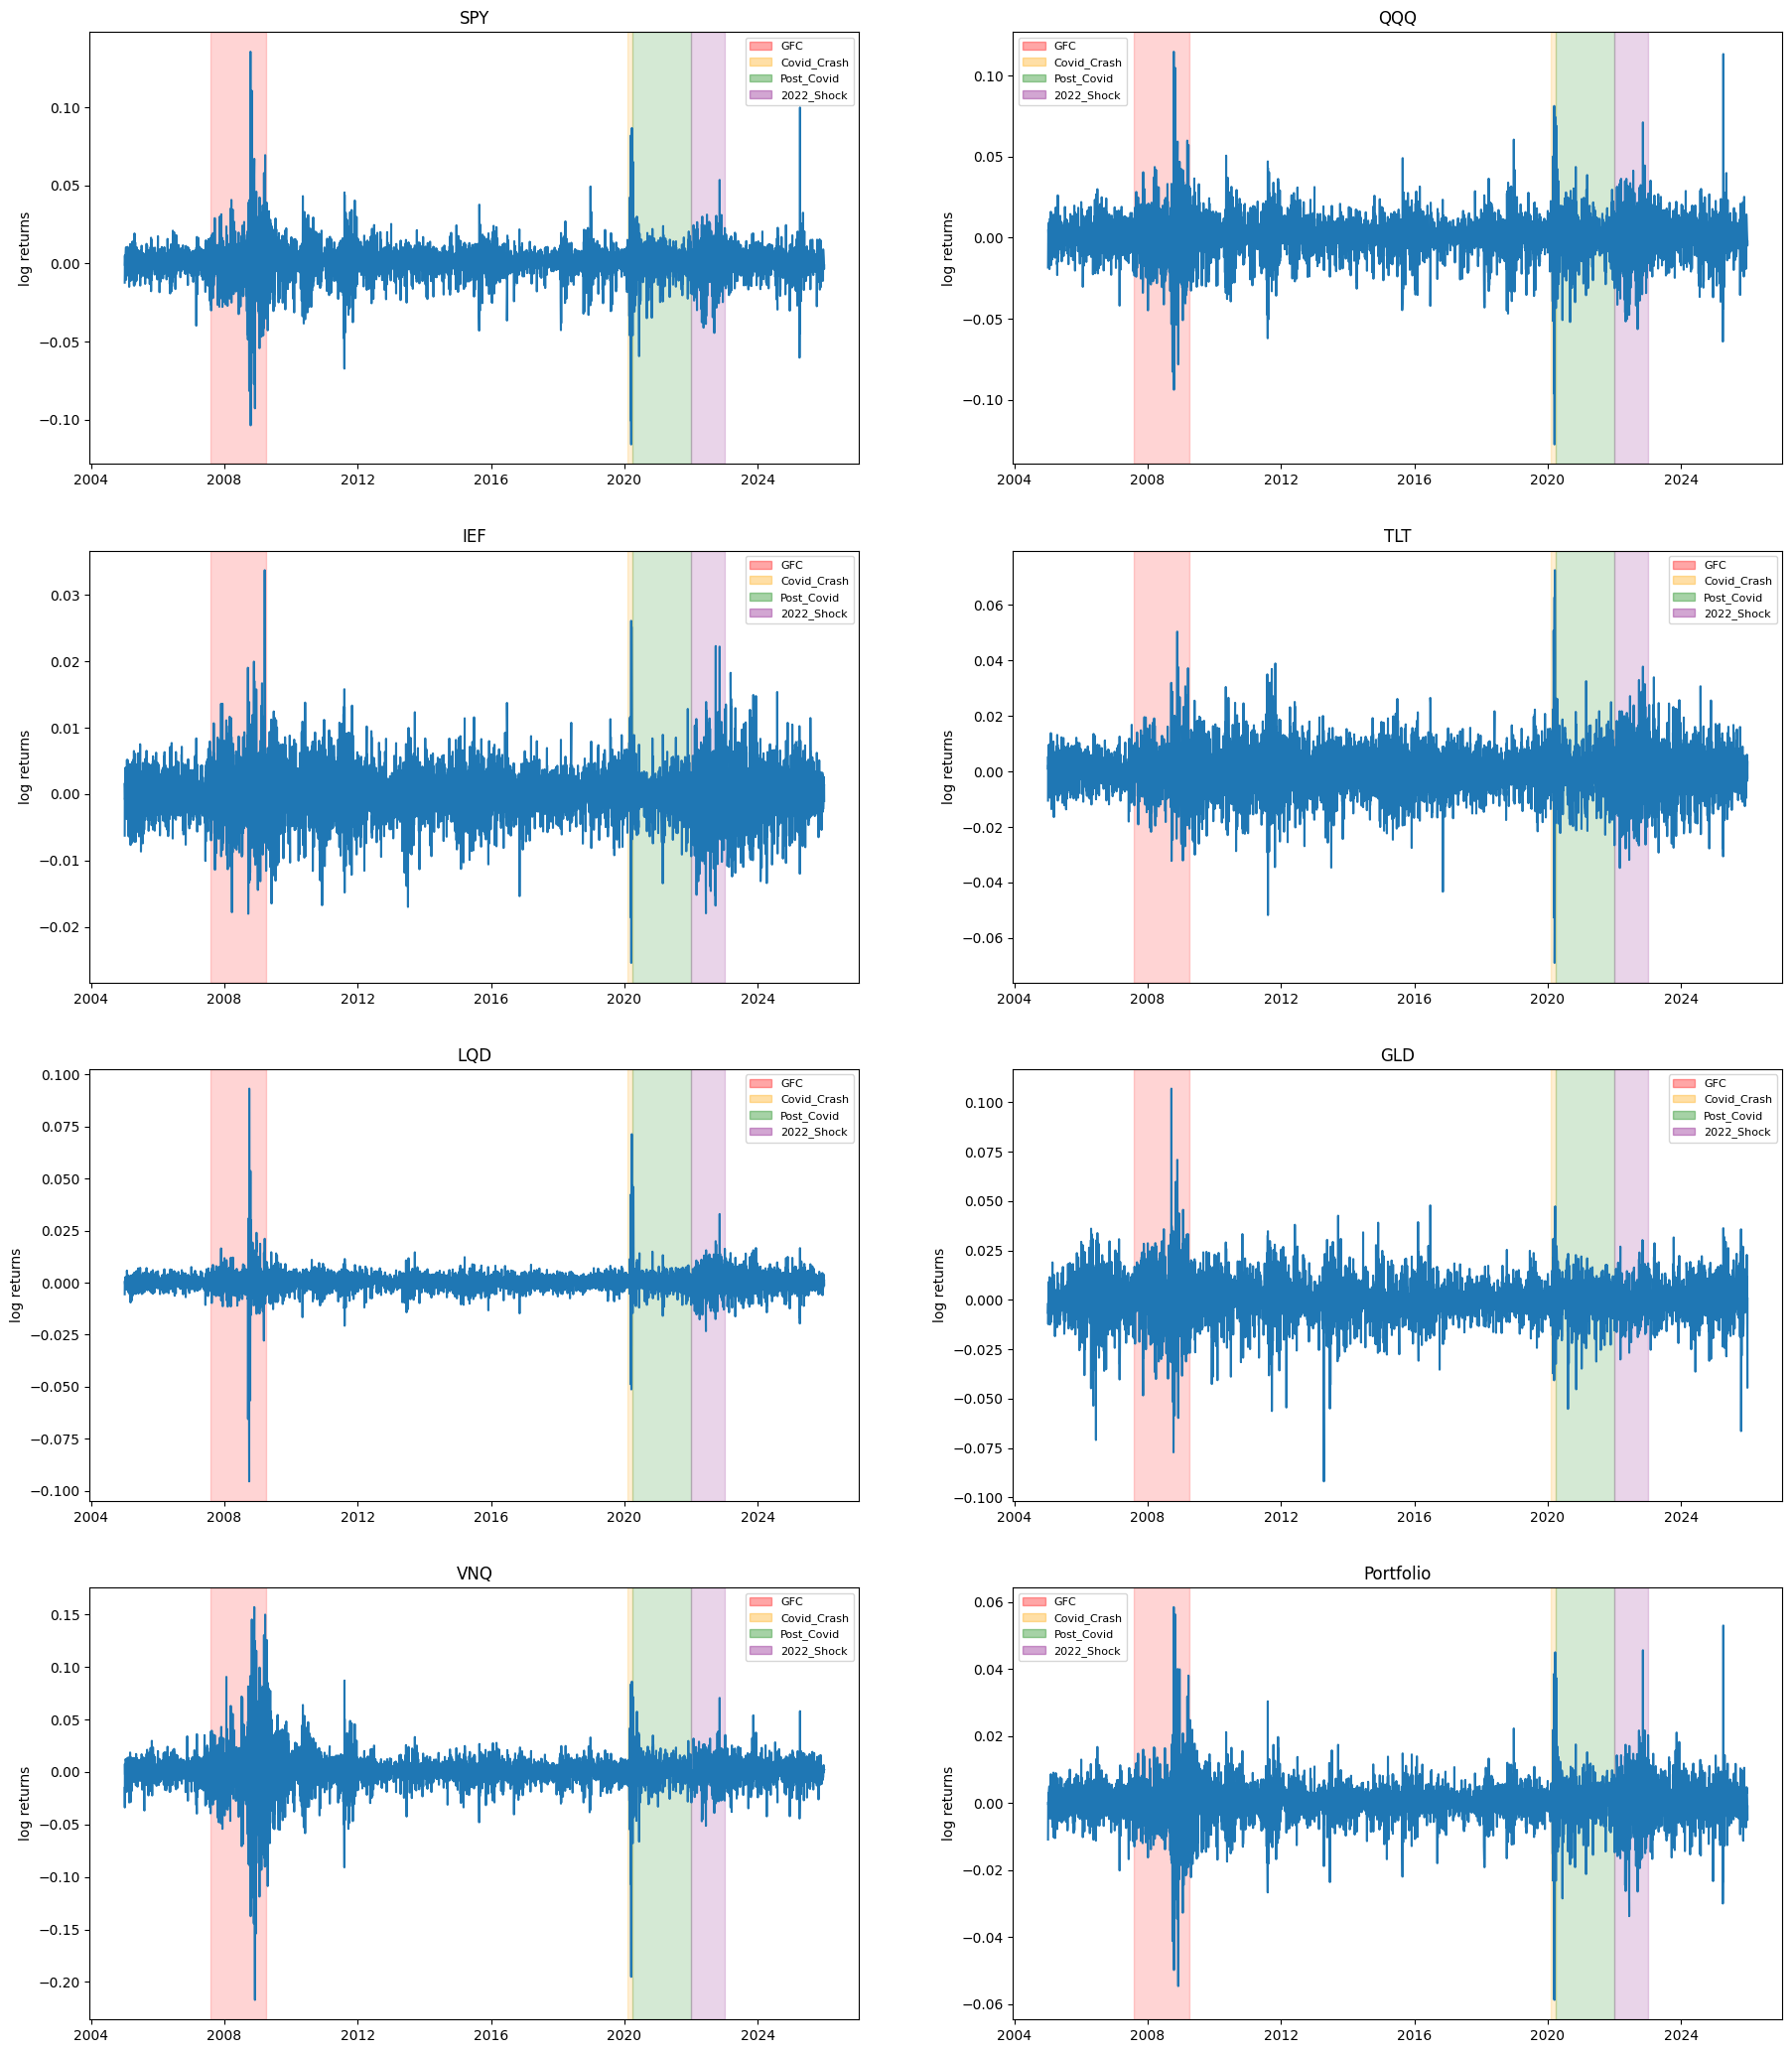

In [82]:
# Plot log returns
def shade_regimes(ax, regimes=REGIMES):
    """
    Shade crisis/regime periods on any time series axis.
    Call after plotting your main series.
    """
    handles = []
    for label, [start, end, color] in regimes.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.17, color=color, label=label)
        handles.append(mpatches.Patch(color=color, alpha=0.15+0.2, label=label))
    return handles


fig, ax = plt.subplots(4, 2, figsize=(22,26))
for i, a in enumerate(ax.flat):
    a.plot(log_returns[log_returns.columns[i]])
    handles = shade_regimes(a)
    a.legend(handles=handles, fontsize=8)
    a.set_ylabel("log returns")
    a.set_title(log_returns.columns[i])


### QQ-plots

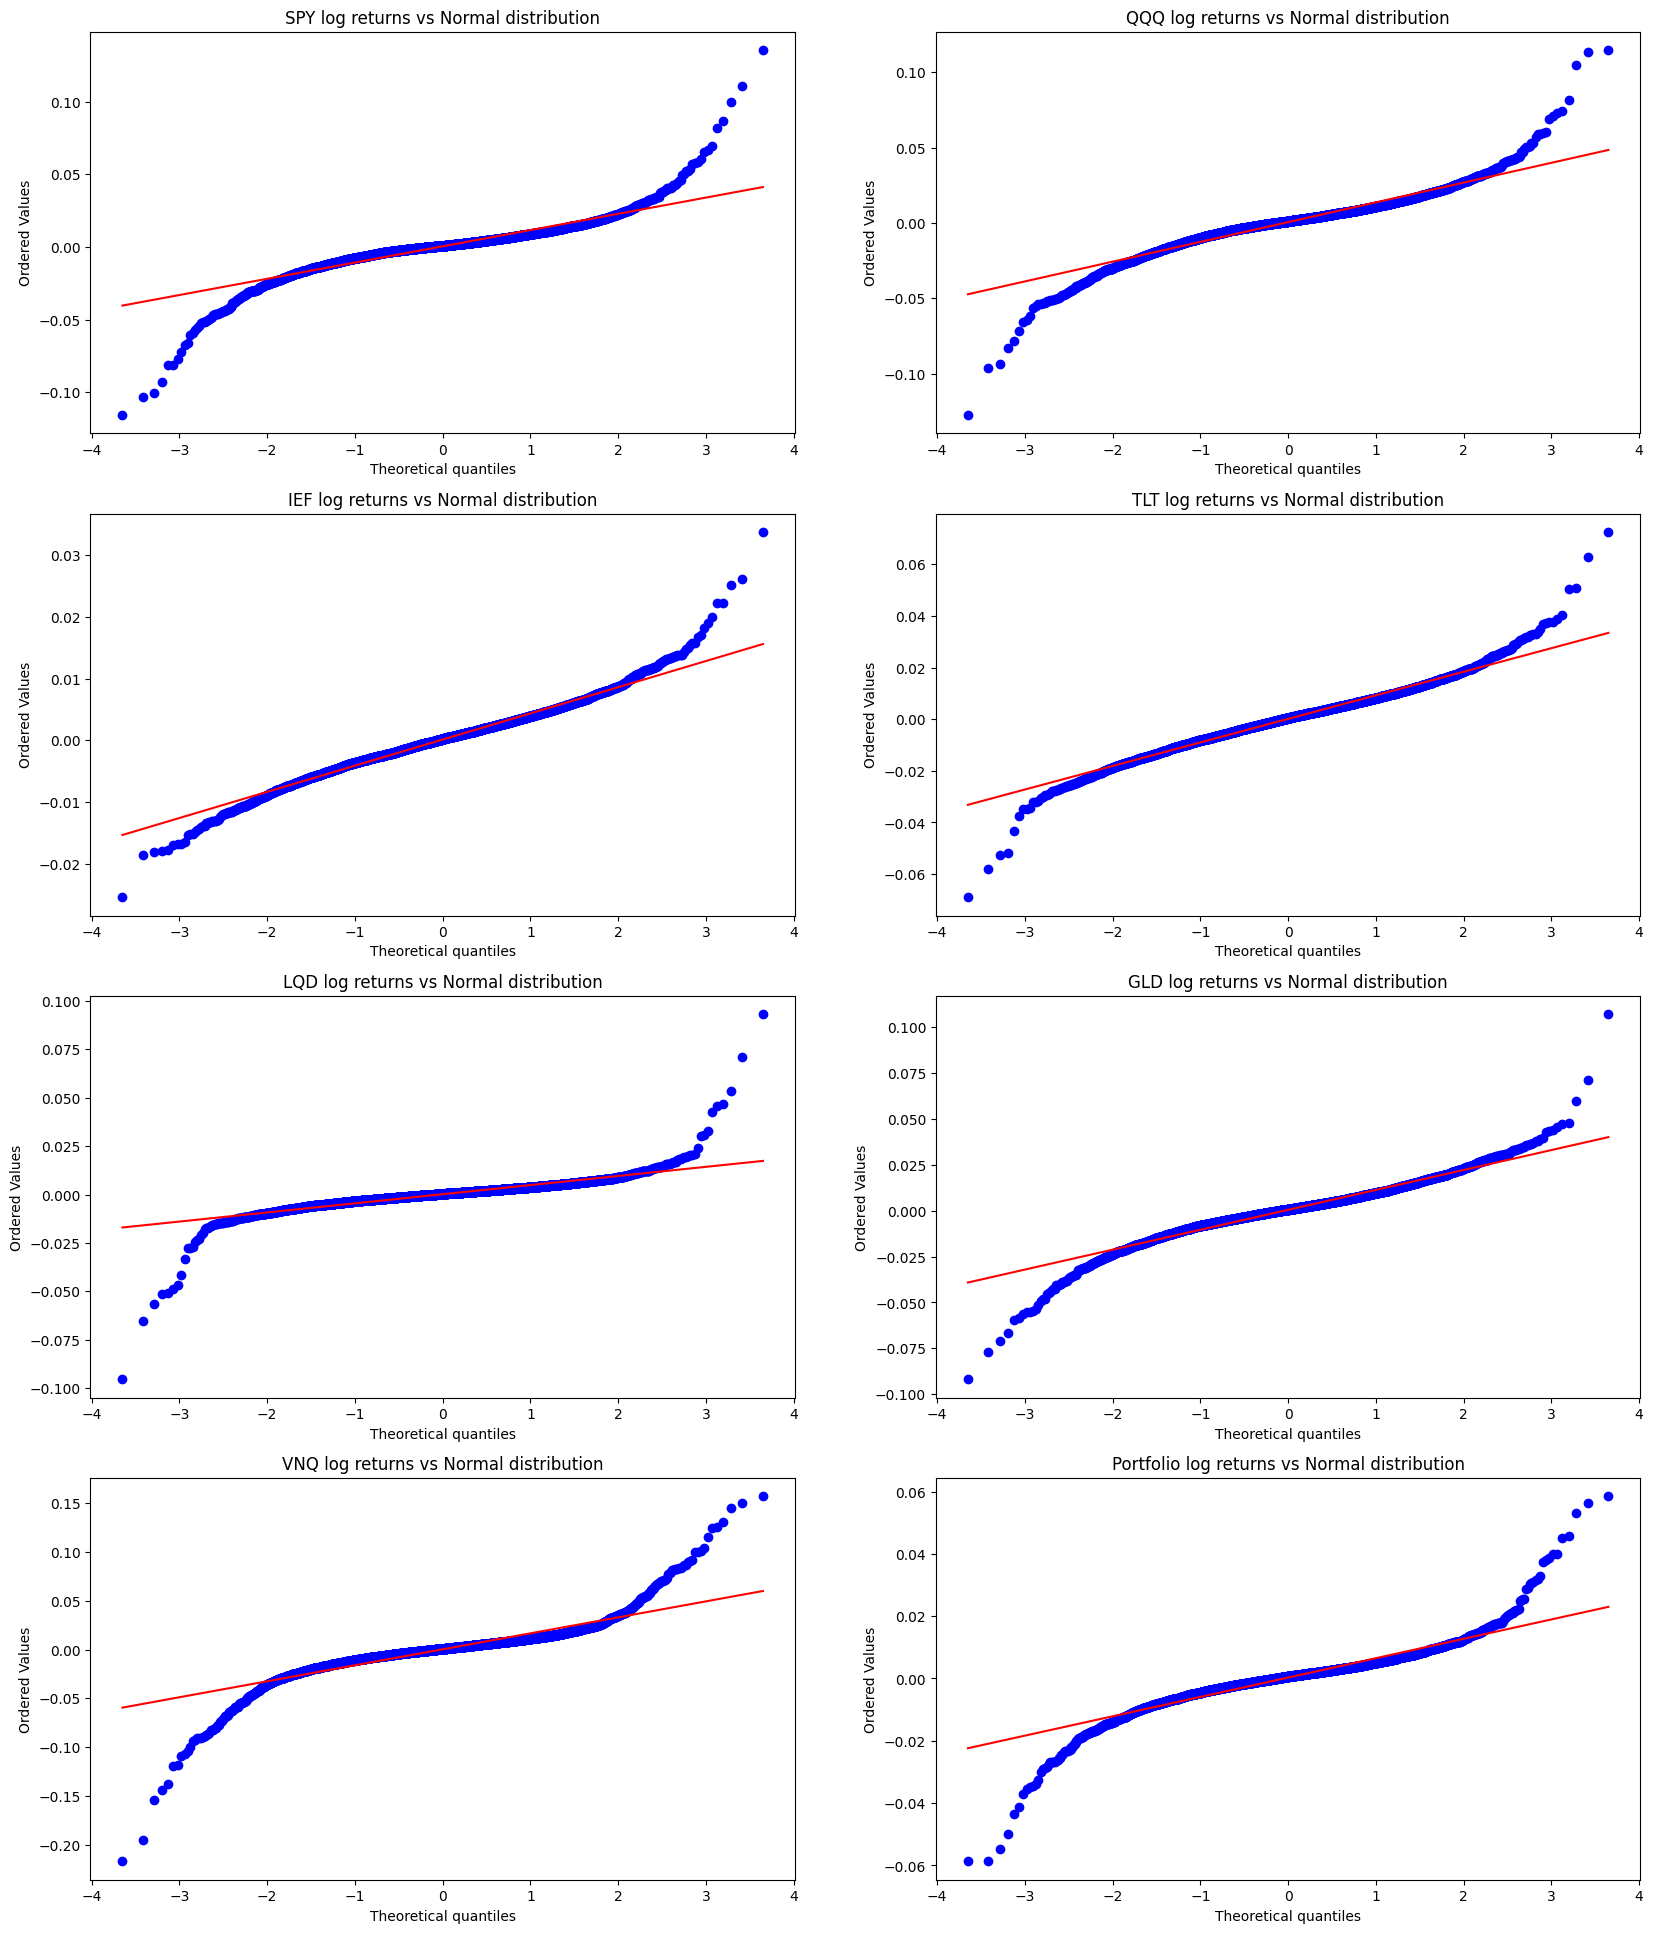

In [83]:
# Q-Q plots to check if there exist heavy tails (Compared to a Gaussian distribution)
def plot_QQ(log_returns: pd.DataFrame):
    columns = log_returns.columns
    fig, ax = plt.subplots(4, 2, figsize=(20,24))
    for i, a in enumerate(ax.flat):
        stats.probplot(log_returns[columns[i]], dist='norm', plot=a)
        a.set_title(f"{columns[i]} log returns vs Normal distribution")

plot_QQ(log_returns)

### Autocorrelation plots

We use ACF plots of squared returns of each asset to examine volatility clusterings.

In [84]:
from statsmodels.graphics.tsaplots import plot_acf

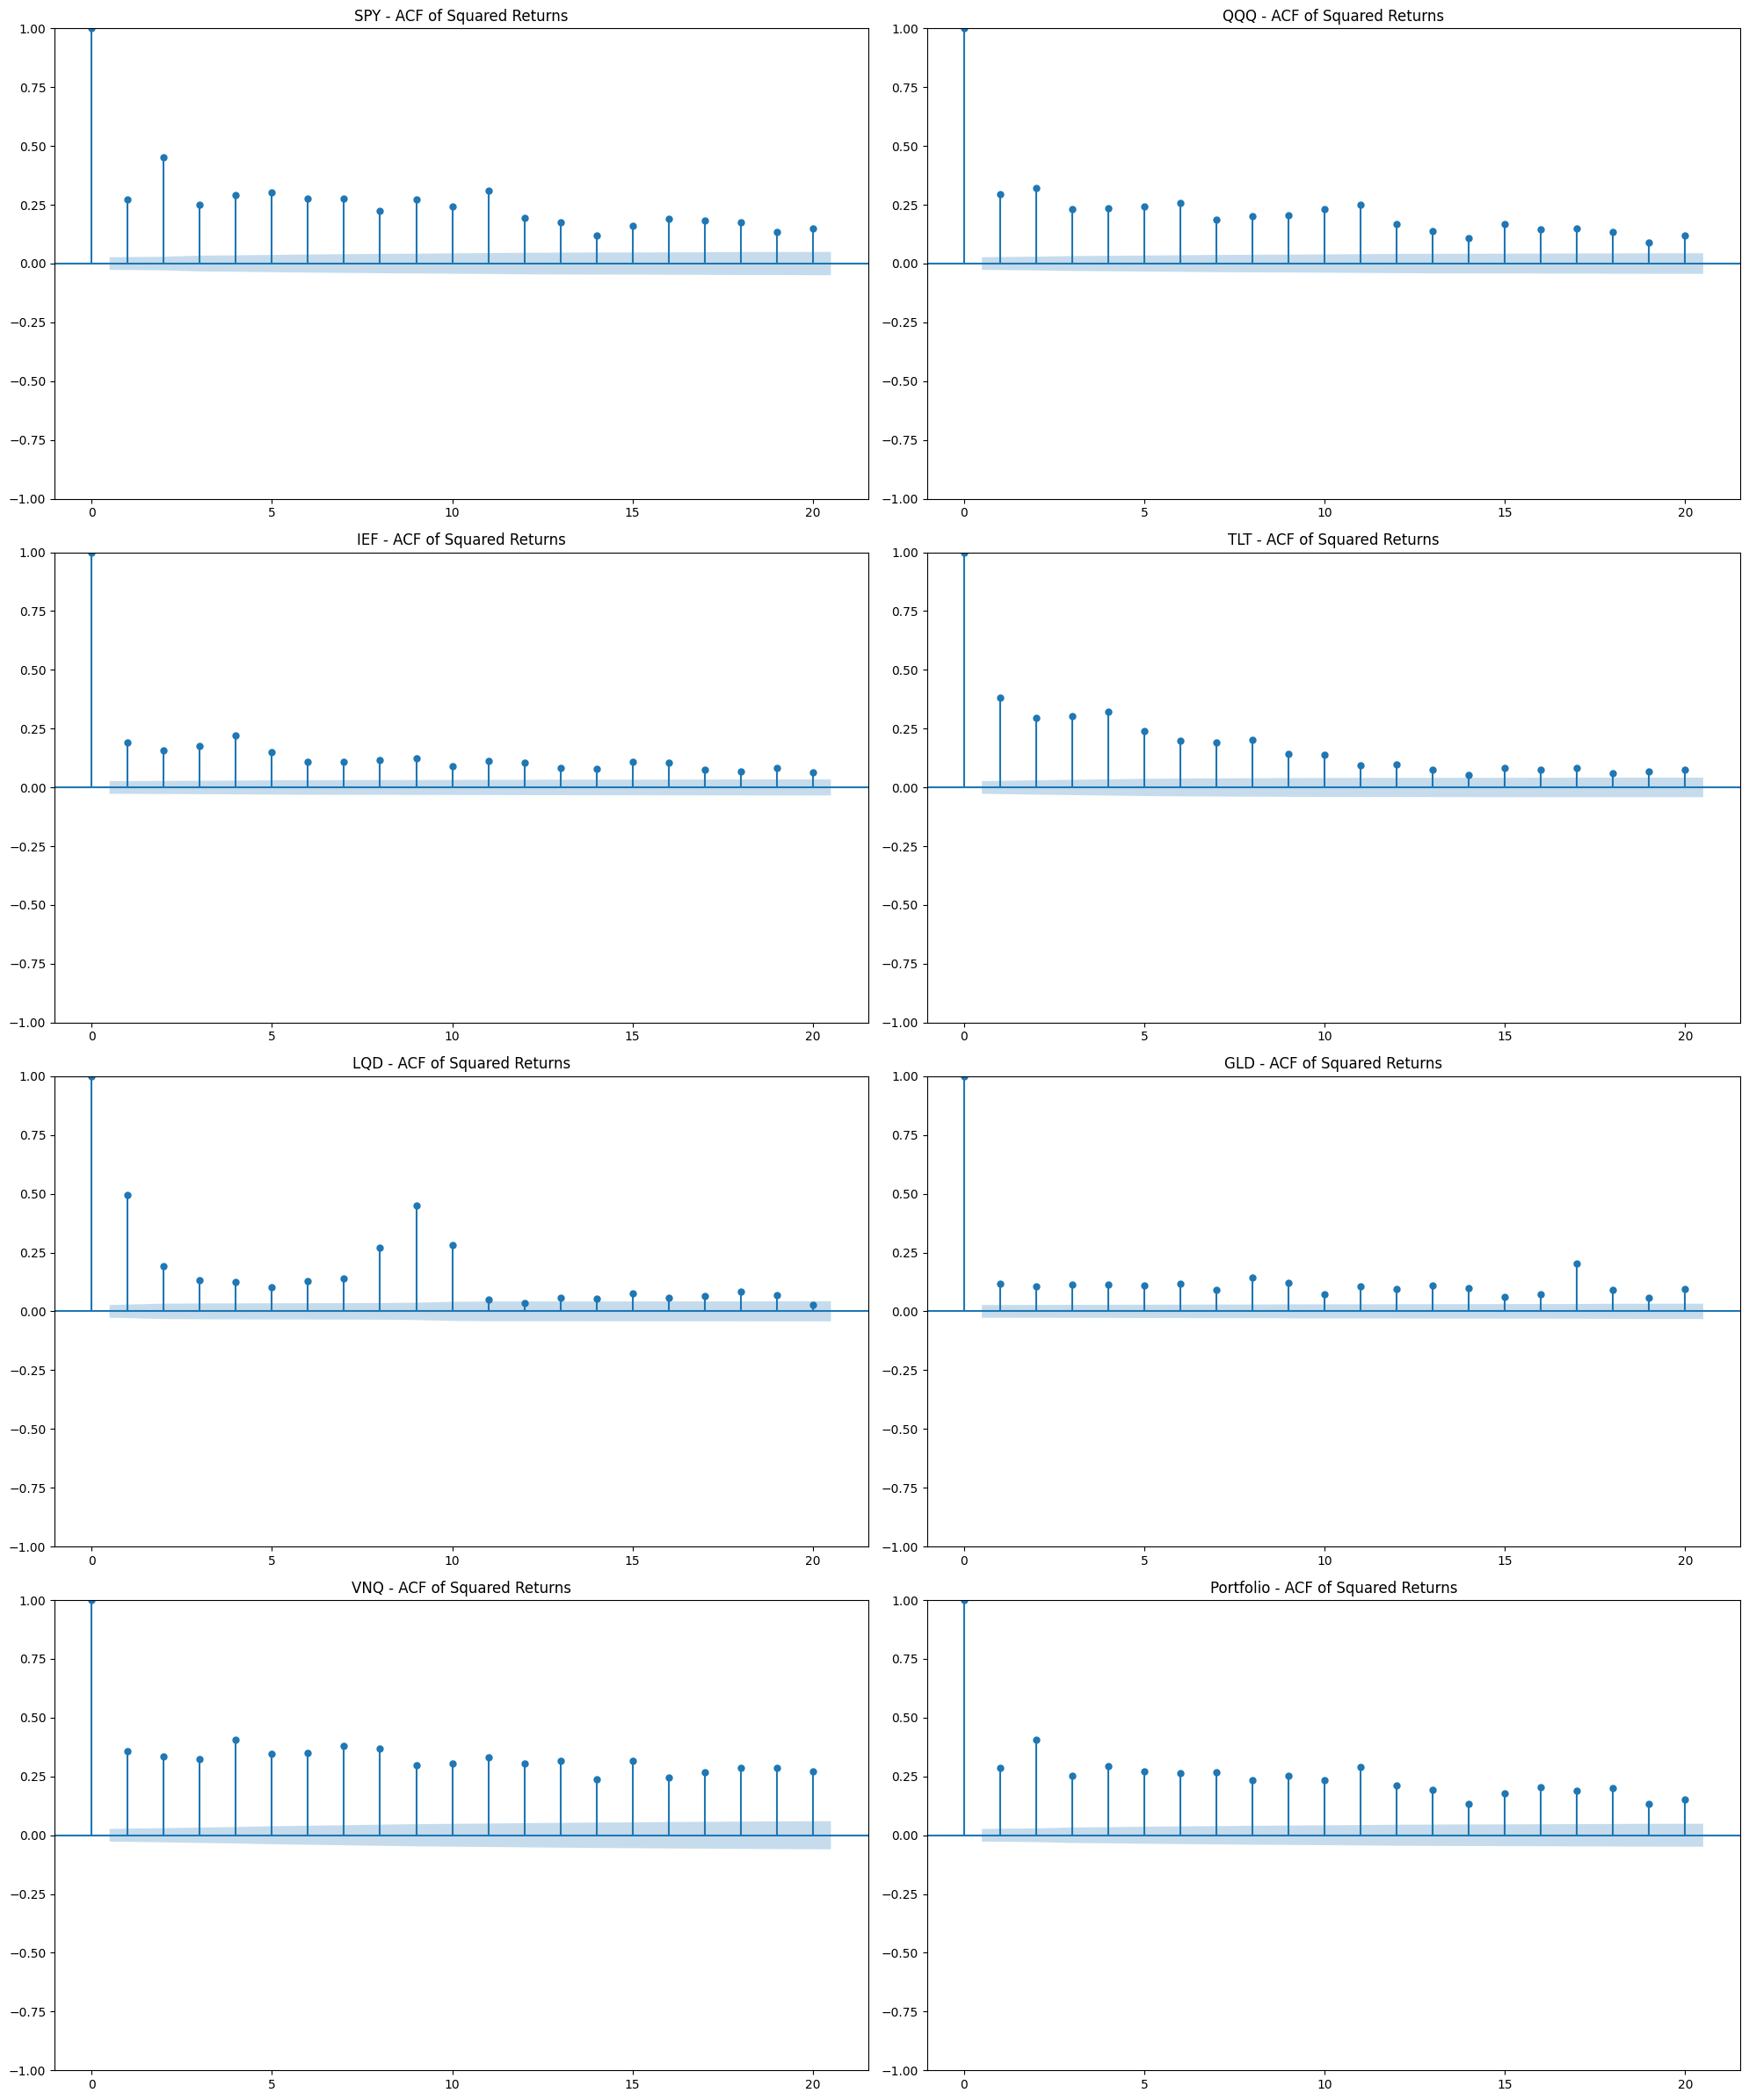

In [85]:
# Plot autocorrelation of squared returns
squared_returns = log_returns**2

fig, ax = plt.subplots(4,2, figsize=(20,24))
for i, a in enumerate(ax.flat):
    plot_acf(squared_returns[log_returns.columns[i]], lags=20, ax=a, title=f"{log_returns.columns[i]} - ACF of Squared Returns")
    
plt.tight_layout()

### Correlation heatmap

We use this plot to check significant correlations between individual assets.

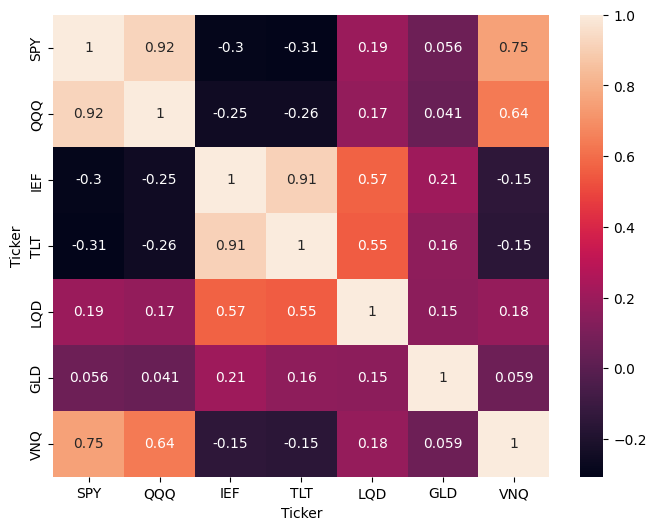

In [86]:
# Plot correlation between assets
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(log_returns[tickers].corr(), annot=True, ax=ax)
plt.show()